In [1]:
import os
import pandas as pd
import random
from PIL import Image
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torchvision
from data_augmentation import get_train_transform, get_test_transform
from data_attack import get_attack_transform
from data_loader import get_dataloader, get_train_test_loaders, get_unlabeled_loader
import matplotlib.pyplot as plt
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [2]:
torch.cuda.is_available()

True

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Assuming that we are on a CUDA machine, this should print a CUDA device:

print(device)

cuda:0


In [4]:
csv_path = '/home/hice1/jguardia7/scratch/datasets/alessandrasala79/ai-vs-human-generated-dataset/versions/4/train.csv'
image_folder = '/home/hice1/jguardia7/scratch/datasets/alessandrasala79/ai-vs-human-generated-dataset/versions/4/train_data'

In [8]:

train_loader, test_loader, attack_loader, train_dataset, test_dataset, attack_dataset = get_train_test_loaders(csv_path, image_folder, augmentation=False, attack_style='SaltAndPepper')
#attack style options: SaltAndPepper, Posterize, GaussNoise, RandomShadow
for images, labels in train_loader:
        print("Train batch shape:", images.shape)
        print("Train labels shape:", labels.shape)
        break

for images, labels in test_loader:
    print("Test batch shape:", images.shape)
    print("Test labels shape:", labels.shape)
    break
    
for images, labels in attack_loader:
    print("Attack test batch shape:", images.shape)
    print("Attack test labels shape:", labels.shape)
    break
    
print(f"Total images in train set: {len(train_dataset)}")
print(f"Total images in test set: {len(test_dataset)}")
print(f"Total images in attack test set: {len(attack_dataset)}")

/storage/ice1/8/1/jguardia7/dl-final-project/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Train batch shape: torch.Size([32, 3, 224, 224])
Train labels shape: torch.Size([32])
Test batch shape: torch.Size([32, 3, 224, 224])
Test labels shape: torch.Size([32])
Attack test batch shape: torch.Size([32, 3, 224, 224])
Attack test labels shape: torch.Size([32])
Total images in train set: 63960
Total images in test set: 15990
Total images in attack test set: 15990


In [9]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

In [11]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.82].


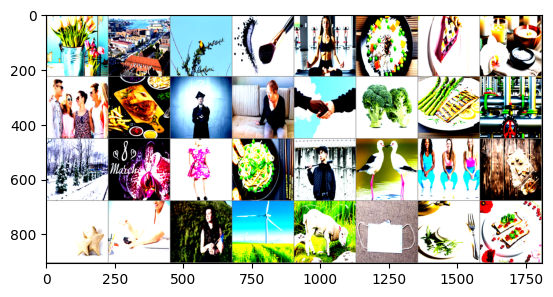

real  generated generated real  real  real  real  real  generated generated generated generated real  generated real  real  generated generated real  real  real  real  real  generated generated generated generated real  real  generated real  real 


In [12]:
# show images
imshow(torchvision.utils.make_grid(images))
# print labels
classes = ('generated','real')
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(32)))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.8199999].


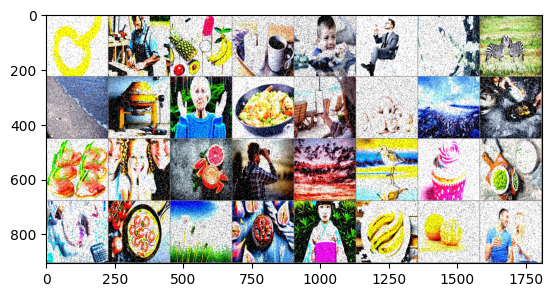

In [13]:
dataattack = iter(attack_loader)
imagesattack = next(dataattack)

# show images
imshow(torchvision.utils.make_grid(imagesattack[0]))

In [14]:
#reference functions from https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html
#hand code 3 convolutions with normalization and relu, doubling channel count each block
#one fully connected layer that outputs two classes
#based on https://arxiv.org/pdf/1912.11035, Resnet is sufficient to train an AI detector
#we hand code the initial block similar to the initial resnet block based on code from
#https://www.digitalocean.com/community/tutorials/writing-resnet-from-scratch-in-pytorch

class ClassifierModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 6, 3),
            nn.BatchNorm2d(6),
            nn.ReLU()
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(6, 12, 4),
            nn.BatchNorm2d(12),
            nn.ReLU()
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(12, 24, 5),
            nn.BatchNorm2d(24),
            nn.ReLU()
        )
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(24 * 25 * 25, 2)


    def forward(self, x):
        x = self.pool(self.block1(x))
        x = self.pool(self.block2(x))
        x = self.pool(self.block3(x))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = self.fc1(x)
        return x


net = ClassifierModel().to(device)


In [15]:
#cross entropy loss since we are training a classifier
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [16]:
#skip if model exists
if os.path.isfile('JuanchitoCNN.pth') != True:
    print('Model does not exist. Training...')
#if model does not exist, train model
    for epoch in range(4):  # loop over the dataset five times

        running_loss = 0.0
        for i, data in enumerate(train_loader, 0):
        # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data[0].to(device), data[1].to(device)
        

        # zero the parameter gradients
            optimizer.zero_grad()

        # forward + backward + optimize
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        # print statistics
            running_loss += loss.item()
            if i % 200 == 199:    # print every 200 mini-batches
                print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
                running_loss = 0.0

    print('Finished Training. Saving...')
    #if model does not exist, save model state directory
    torch.save(net.state_dict(), 'JuanchitoCNN.pth')
    print('Saved.')
else:
    print('Model exists. Loading weights')
    net.load_state_dict(torch.load('JuanchitoCNN.pth', weights_only=True))
    net.eval()
    print('Weights loaded')

Model exists. Loading weights
Weights loaded


In [17]:
correct = 0
total = 0
with torch.no_grad():
    for i, data in enumerate(test_loader, 0):
        images, labels = data[0].to(device), data[1].to(device)
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        if i % 200 == 199:    # print every 200 mini-batches
            print(f'[{i + 1:5d}]')

[  200]
[  400]


In [18]:
print(f'Accuracy of the network on the test images: {100 * correct // total} %')

Accuracy of the network on the test images: 93 %


In [19]:
correct = 0
total = 0
with torch.no_grad():
    for i, data in enumerate(attack_loader, 0):
        images, labels = data[0].to(device), data[1].to(device)
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        if i % 200 == 199:    # print every 200 mini-batches
            print(f'[{i + 1:5d}]')

[  200]
[  400]


In [20]:
print(f'Accuracy of the network on the attack images, saltpepper attack: {100 * correct // total} %')

Accuracy of the network on the attack images, saltpepper attack: 49 %


In [21]:
_, _, attack_loader, _, _, attack_dataset = get_train_test_loaders(csv_path, image_folder, augmentation=False, attack_style='Posterize')
#attack style options: SaltAndPepper, Posterize, GaussNoise, RandomShadow

/storage/ice1/8/1/jguardia7/dl-final-project/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
correct = 0
total = 0
with torch.no_grad():
    for i, data in enumerate(attack_loader, 0):
        images, labels = data[0].to(device), data[1].to(device)
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        if i % 200 == 199:    # print every 200 mini-batches
            print(f'[{i + 1:5d}]')

In [ ]:
print(f'Accuracy of the network on the attack images, posterize attack: {100 * correct // total} %')

In [ ]:
_, _, attack_loader, _, _, attack_dataset = get_train_test_loaders(csv_path, image_folder, augmentation=False, attack_style='GaussNoise')
#attack style options: SaltAndPepper, Posterize, GaussNoise, RandomShadow

In [ ]:
correct = 0
total = 0
with torch.no_grad():
    for i, data in enumerate(attack_loader, 0):
        images, labels = data[0].to(device), data[1].to(device)
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        if i % 200 == 199:    # print every 200 mini-batches
            print(f'[{i + 1:5d}]')

In [ ]:
print(f'Accuracy of the network on the attack images, gaussnoise attack: {100 * correct // total} %')

In [ ]:
_, _, attack_loader, _, _, attack_dataset = get_train_test_loaders(csv_path, image_folder, augmentation=False, attack_style='RandomShadow')
#attack style options: SaltAndPepper, Posterize, GaussNoise, RandomShadow

In [ ]:
correct = 0
total = 0
with torch.no_grad():
    for i, data in enumerate(attack_loader, 0):
        images, labels = data[0].to(device), data[1].to(device)
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        if i % 200 == 199:    # print every 200 mini-batches
            print(f'[{i + 1:5d}]')

In [ ]:
print(f'Accuracy of the network on the attack images, randomshadow attack: {100 * correct // total} %')

In [ ]:
# Get parameters for Juanchito CNN
model = ClassifierModel()
print(model)

# Total number of parameters
total_params = sum(p.numel() for p in model.parameters())

# Total trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

In [ ]:
# Get Flops for Juanchito CNN
from ptflops import get_model_complexity_info

# Instantiate your model
model = CLassifierModel()
model = model.cpu()  # Move to CPU for ptflops

# Define input shape
input_shape = (3, 224, 224)

# Get FLOPs and parameters
macs, params = get_model_complexity_info(
    model,
    input_shape,
    as_strings=False,
    print_per_layer_stat=True  # See per-layer if you want
)

flops = macs * 2
print(f"FLOPs: {flops/1e9:.2f} G") 
print(f"Parameters: {params/1e6:.2f} M")
